In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/ML/driver-data.csv")

In [ ]:
X = data[['mean_dist_day', 'mean_over_speed_perc']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

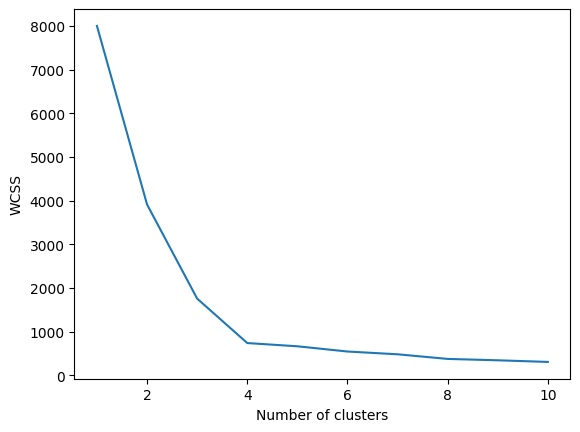

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
print(data.groupby('Cluster').mean())

                   id  mean_dist_day  mean_over_speed_perc
Cluster                                                   
0        3.423312e+09      50.000796              5.972079
1        3.423312e+09     180.443545             10.492795
2        3.423313e+09      83.669037             45.128395


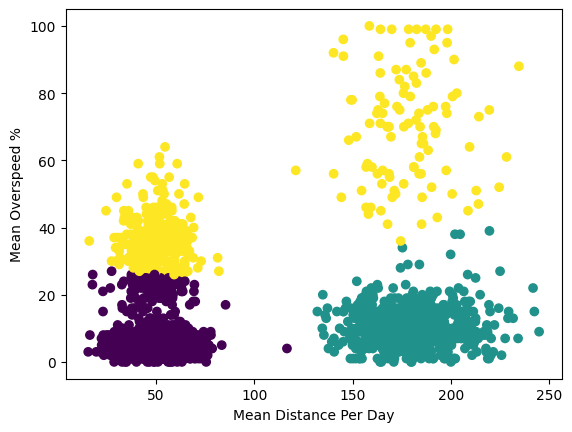

In [25]:
plt.scatter(data['mean_dist_day'], data['mean_over_speed_perc'], c=data['Cluster'])
plt.xlabel("Mean Distance Per Day")
plt.ylabel("Mean Overspeed %")
plt.show()

In [ ]:
data.to_csv("clustered_drivers.csv", index=False)